<a href="https://colab.research.google.com/github/Gnanapravallika/retinal-oct-ae-resnet/blob/main/AE_ResNet_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AE-ResNet: Retinal OCT Trustworthy AI Pipeline (Frozen v3.0)
### Research Question:
Can attention-guided feature learning improve both retinal OCT classification performance and explanation faithfulness while maintaining robust generalization under external validation?

---
## SECTION 1: Environment Setup

In [3]:
import os

# Make sure we are in the right directory
os.chdir('/content')

In [4]:
!rm -rf /content/retinal-oct-ae-resnet
!git clone https://github.com/Gnanapravallika/retinal-oct-ae-resnet.git
%cd /content/retinal-oct-ae-resnet

Cloning into 'retinal-oct-ae-resnet'...
remote: Enumerating objects: 290, done.
remote: Counting objects: 100% (290/290), done.
remote: Compressing objects: 100% (148/148), done.
remote: Total 290 (delta 148), reused 274 (delta 132), pack-reused 0 (from 0)
Receiving objects: 100% (290/290), 12.75 MiB | 15.52 MiB/s, done.
Resolving deltas: 100% (148/148), done.
/content/retinal-oct-ae-resnet


In [5]:
# Setup imports
import os
import sys
import time
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Running on device: {device}')

Running on device: cuda


In [6]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## SECTION 2: Dataset Verification & Statistics
Loads the training mappings and dynamically computes **Table 1: Dataset Statistics**.

In [7]:
# Load dataset mappings dynamically (Self-Healing Cell)
from src.dataset.dataset import auto_detect_columns, patient_level_split

drive_base = '/content/drive/MyDrive'
csv_path = '/content/octdl_dataset_mapping.csv'

# 1. Automatically generate the CSV file if missing after restart
if not os.path.exists(csv_path):
    print('🔄 CSV mapping file missing after restart. Generating dynamically from Google Drive...')
    root_octdl = os.path.join(drive_base, 'OCTDL')
    if not os.path.exists(root_octdl):
        raise FileNotFoundError("❌ Error: 'OCTDL' folder not found in your Google Drive root. Please upload it!")

    records = []
    class_to_idx = {'amd': 0, 'dme': 1, 'erm': 2, 'no': 3, 'rao': 4, 'rvo': 5, 'vid': 6}
    classes = [d for d in os.listdir(root_octdl) if os.path.isdir(os.path.join(root_octdl, d))]

    for cls in classes:
        cls_path = os.path.join(root_octdl, cls)
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        for idx, f in enumerate(files):
            synthetic_patient = f'{cls}_Pat_{idx // 10 + 1}'
            records.append({
                'image_path': os.path.join(cls_path, f),
                'label': class_to_idx.get(cls.lower(), -1),
                'patient_id': synthetic_patient
            })

    df_new = pd.DataFrame(records)
    df_new = df_new[df_new['label'] != -1]
    df_new.to_csv(csv_path, index=False)
    print(f'✅ Success: Dynamically created mapping CSV with {len(df_new)} images.')

# 2. Read the verified CSV mapping
df = auto_detect_columns(pd.read_csv(csv_path))

# 3. Double-check path validity and convert if Windows paths exist
sample_img_path = df.iloc[0]['image_path']
if not os.path.exists(sample_img_path):
    print('Attempting automatic path correction...')
    def convert_path_to_colab(win_path):
        linux_path = win_path.replace('\\', '/')
        relative_path = linux_path[linux_path.find('OCTDL/'):] if 'OCTDL/' in linux_path else '/'.join(linux_path.split('/')[-3:])
        return os.path.join(drive_base, relative_path)
    df['image_path'] = df['image_path'].apply(convert_path_to_colab)
    sample_img_path = df.iloc[0]['image_path']

# 4. Perform patient split
train_df, val_df, test_df = patient_level_split(df)
print(f'Dataset successfully loaded. Train shape: {train_df.shape}')
print(f'Does sample image exist? {os.path.exists(sample_img_path)}')

Dataset successfully loaded. Train shape: (1348, 3)
Does sample image exist? True


In [8]:
total = len(df)

print(f"Train: {len(train_df)} ({100*len(train_df)/total:.2f}%)")
print(f"Validation: {len(val_df)} ({100*len(val_df)/total:.2f}%)")
print(f"Test: {len(test_df)} ({100*len(test_df)/total:.2f}%)")

Train: 1348 (65.31%)
Validation: 316 (15.31%)
Test: 400 (19.38%)


In [9]:
print("Unique patients")
print("Train:", train_df["patient_id"].nunique())
print("Validation:", val_df["patient_id"].nunique())
print("Test:", test_df["patient_id"].nunique())

Unique patients
Train: 137
Validation: 32
Test: 42


In [10]:
train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
test_patients = set(test_df["patient_id"])

print("Train-Val overlap:", len(train_patients & val_patients))
print("Train-Test overlap:", len(train_patients & test_patients))
print("Val-Test overlap:", len(val_patients & test_patients))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [11]:
# Patient Leakage Check
train_patients = set(train_df['patient_id'].unique())
test_patients = set(test_df['patient_id'].unique())
leakage = train_patients.intersection(test_patients)
print(f'Patient overlap count: {len(leakage)}')
assert len(leakage) == 0, '⚠️ CRITICAL error: Patient data leakage detected!'
print('✅ Success: Zero patient leakage verified.')

Patient overlap count: 0
✅ Success: Zero patient leakage verified.


In [12]:
# Compute Table 1 dynamically (mapping indices back to class names)
CLASSES = ['AMD', 'DME', 'ERM', 'NO', 'RAO', 'RVO', 'VID']
table_1 = df.groupby('label').agg(
    total_images=('image_path', 'count'),
    unique_patients=('patient_id', 'nunique')
).reset_index().rename(columns={'label': 'Diagnostic Class', 'total_images': 'Total Images', 'unique_patients': 'Unique Patients'})
table_1['Diagnostic Class'] = table_1['Diagnostic Class'].apply(lambda x: CLASSES[int(x)])
print('--- TABLE 1: DATASET STATISTICS (COMPUTED) ---')
display(table_1)
os.makedirs('results/tables', exist_ok=True)
table_1.to_csv('results/tables/table_1_dataset_statistics.csv', index=False)

--- TABLE 1: DATASET STATISTICS (COMPUTED) ---


,Diagnostic Class,Total Images,Unique Patients
0,AMD,1231,124
1,DME,147,15
2,ERM,155,16
3,NO,332,34
4,RAO,22,3
5,RVO,101,11
6,VID,76,8


## SECTION 3: Preprocessing & Denoising
Applies and visualizes edge-preserving speckle denoising (Bilateral filtering) on training B-scans.

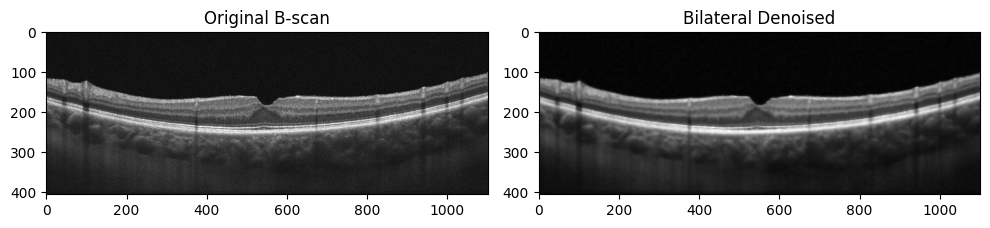

In [13]:
# Visualizing Preprocessing
from src.preprocessing.filters import bilateral_filter

sample_path = df.iloc[0]['image_path']
raw_img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
processed_img = bilateral_filter(raw_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw_img, cmap='gray'); axes[0].set_title('Original B-scan')
axes[1].imshow(processed_img, cmap='gray'); axes[1].set_title('Bilateral Denoised')
plt.tight_layout()
os.makedirs('results/figures', exist_ok=True)
plt.savefig('results/figures/figure_1_preprocessing.png', dpi=300)
plt.show()

## SECTION 4: Baseline Models Setup
Loads the comparison backbones (ResNet-50, DenseNet-121, ).

In [1]:
# 1. Reset directory
%cd /content

# 2. Delete and re-clone the fresh repo
!rm -rf /content/retinal-oct-ae-resnet
!git clone https://github.com/Gnanapravallika/retinal-oct-ae-resnet.git

# 3. Change directory
%cd /content/retinal-oct-ae-resnet

/content
Cloning into 'retinal-oct-ae-resnet'...
remote: Enumerating objects: 290, done.
remote: Counting objects: 100% (290/290), done.
remote: Compressing objects: 100% (148/148), done.
remote: Total 290 (delta 148), reused 274 (delta 132), pack-reused 0 (from 0)
Receiving objects: 100% (290/290), 12.75 MiB | 15.09 MiB/s, done.
Resolving deltas: 100% (148/148), done.
/content/retinal-oct-ae-resnet


In [2]:
from src.models.ae_resnet_v2.model import get_model_v2 as get_model_architecture

# Configure pre-trained architectures
resnet_baseline = get_model_architecture('resnet50', num_classes=7, pretrained=True)
densenet_baseline = get_model_architecture('densenet121', num_classes=7, pretrained=True)
print('Pre-trained baselines loaded.')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 80.2MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 59.7MB/s]


Pre-trained baselines loaded.


## SECTION 5: Proposed AE-ResNet Model
Loads the attention-gated ResNet backbone with sequentially integrated Channel-Spatial Attention (CSA).

In [14]:
from src.models.ae_resnet import AEResNet

ae_resnet_model = AEResNet(num_classes=7, pretrained=True).to(device)
print('AE-ResNet successfully initialized with pre-trained weights.')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


AE-ResNet successfully initialized with pre-trained weights.


## SECTION 6: Model Training Execution
Trains each baseline model and the proposed AE-ResNet model separately under identical hyperparameters.

In [15]:
from src.training.trainer_v2 import train_model_v2

# Train all backbones separately to compile comparative results
train_model_v2(model_name='resnet50', csv_path=csv_path, epochs=40)


--- Split Class Distributions ---
Class      | Train    | Val      | Test    
---------------------------------------------
AMD        | 850      | 190      | 191     
DME        | 90       | 20       | 37      
ERM        | 95       | 20       | 40      
Normal     | 212      | 50       | 70      
RAO        | 10       | 10       | 2       
RVO        | 51       | 20       | 30      
VID        | 40       | 6        | 30      
---------------------------------------------
Training resnet50 for 40 epochs on cuda...
Epoch 1/40 | Loss: 1.8724 Acc: 0.3405 | Val Loss: 1.8649 Acc: 0.2848 F1: 0.2073
✅ Best model updated! Val Macro F1: 0.2073
Epoch 2/40 | Loss: 1.5278 Acc: 0.6328 | Val Loss: 1.5343 Acc: 0.5190 F1: 0.4661
✅ Best model updated! Val Macro F1: 0.4661
Epoch 3/40 | Loss: 0.9668 Acc: 0.8064 | Val Loss: 1.0780 Acc: 0.7057 F1: 0.5881
✅ Best model updated! Val Macro F1: 0.5881
Epoch 4/40 | Loss: 0.5944 Acc: 0.8568 | Val Loss: 0.7183 Acc: 0.7975 F1: 0.6789
✅ Best model updated! Val Mac

In [16]:
from src.training.trainer_v2 import train_model_v2

# Train all backbones separately to compile comparative results
train_model_v2(model_name='densenet121', csv_path=csv_path, epochs=40)


--- Split Class Distributions ---
Class      | Train    | Val      | Test    
---------------------------------------------
AMD        | 850      | 190      | 191     
DME        | 90       | 20       | 37      
ERM        | 95       | 20       | 40      
Normal     | 212      | 50       | 70      
RAO        | 10       | 10       | 2       
RVO        | 51       | 20       | 30      
VID        | 40       | 6        | 30      
---------------------------------------------
Training densenet121 for 40 epochs on cuda...
Epoch 1-3 Warm-up: densenet121 Backbone frozen (training new layers only)
Epoch 1/40 | Loss: 1.9491 Acc: 0.1588 | Val Loss: 1.8626 Acc: 0.2500 F1: 0.2148
✅ Best model updated! Val Macro F1: 0.2148
Epoch 2/40 | Loss: 1.8006 Acc: 0.3249 | Val Loss: 1.8424 Acc: 0.2848 F1: 0.2344
✅ Best model updated! Val Macro F1: 0.2344
Epoch 3/40 | Loss: 1.6950 Acc: 0.4503 | Val Loss: 1.8789 Acc: 0.2627 F1: 0.2554
✅ Best model updated! Val Macro F1: 0.2554
Epoch 4: densenet121 Backbone un

In [17]:
from src.training.trainer_v2 import train_model_v2

# Train ablation configurations
train_model_v2(model_name='resnet_fixed_fusion', csv_path=csv_path, epochs=40)
train_model_v2(model_name='ae_resnet_v1', csv_path=csv_path, epochs=40)
train_model_v2(model_name='resnet_amsf', csv_path=csv_path, epochs=40)


--- Split Class Distributions ---
Class      | Train    | Val      | Test    
---------------------------------------------
AMD        | 850      | 190      | 191     
DME        | 90       | 20       | 37      
ERM        | 95       | 20       | 40      
Normal     | 212      | 50       | 70      
RAO        | 10       | 10       | 2       
RVO        | 51       | 20       | 30      
VID        | 40       | 6        | 30      
---------------------------------------------
Training resnet_fixed_fusion for 40 epochs on cuda...
Epoch 1-3 Warm-up: resnet_fixed_fusion Backbone frozen (training new layers only)
Epoch 1/40 | Loss: 1.6989 Acc: 0.3887 | Val Loss: 1.6983 Acc: 0.3987 F1: 0.3538
✅ Best model updated! Val Macro F1: 0.3538
Epoch 2/40 | Loss: 1.3071 Acc: 0.6053 | Val Loss: 1.4063 Acc: 0.5443 F1: 0.4440
✅ Best model updated! Val Macro F1: 0.4440
Epoch 3/40 | Loss: 1.0488 Acc: 0.7404 | Val Loss: 1.1402 Acc: 0.7089 F1: 0.5363
✅ Best model updated! Val Macro F1: 0.5363
Epoch 4: resnet_

In [19]:
from src.training.trainer_v2 import train_model_v2

# Train proposed model (AE-ResNet v2)
train_model_v2(model_name='ae_resnet_v2', csv_path=csv_path, epochs=40)


--- Split Class Distributions ---
Class      | Train    | Val      | Test    
---------------------------------------------
AMD        | 850      | 190      | 191     
DME        | 90       | 20       | 37      
ERM        | 95       | 20       | 40      
Normal     | 212      | 50       | 70      
RAO        | 10       | 10       | 2       
RVO        | 51       | 20       | 30      
VID        | 40       | 6        | 30      
---------------------------------------------
Training ae_resnet_v2 for 40 epochs on cuda...
Epoch 1-3 Warm-up: ae_resnet_v2 Backbone frozen (training new layers only)
Epoch 1/40 | Loss: 1.8684 Acc: 0.3427 | Val Loss: 1.7892 Acc: 0.6329 F1: 0.4315
✅ Best model updated! Val Macro F1: 0.4315
Epoch 2/40 | Loss: 1.6219 Acc: 0.5631 | Val Loss: 1.5465 Acc: 0.6424 F1: 0.4695
✅ Best model updated! Val Macro F1: 0.4695
Epoch 3/40 | Loss: 1.3624 Acc: 0.6818 | Val Loss: 1.3009 Acc: 0.7120 F1: 0.5261
✅ Best model updated! Val Macro F1: 0.5261
Epoch 4: ae_resnet_v2 Backbone

## SECTION 7: Classification Evaluation
Evaluates **all models** dynamically by loading their best checkpoints, and compiles the comparison **Table 2**. Also plots the Confusion Matrix and per-class performance tables.

In [20]:
# Section 7: Complete Peer-Review Evaluation Pipeline
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    confusion_matrix, classification_report, roc_auc_score
)
from src.dataset.dataset import RetinalDataset
from src.models.ae_resnet_v2.model import get_model_v2 as get_model_architecture

val_transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])
test_dataset = RetinalDataset(test_df, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

def compute_ece(y_true, y_probs, n_bins=10):
    confidences = np.max(y_probs, axis=1)
    predictions = np.argmax(y_probs, axis=1)
    accuracies = (predictions == y_true)

    ece = 0.0
    for i in range(n_bins):
        bin_lower = i / n_bins
        bin_upper = (i + 1) / n_bins
        in_bin = (confidences >= bin_lower) & (confidences < bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(accuracies[in_bin])
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
    return ece

def compute_brier_score(y_true, y_probs):
    n_classes = y_probs.shape[1]
    y_one_hot = np.eye(n_classes)[y_true]
    return np.mean(np.sum((y_probs - y_one_hot) ** 2, axis=1))

def compute_multiclass_specificity(y_true, y_pred, present_classes):
    specificities = []
    for c in present_classes:
        tn, fp, fn, tp = confusion_matrix(y_true == c, y_pred == c, labels=[False, True]).ravel()
        spec_c = tn / (tn + fp + 1e-9)
        specificities.append(spec_c)
    return np.mean(specificities)

def compute_all_metrics(labels, preds, probs):
    labels = np.array(labels)
    preds = np.array(preds)
    probs = np.array(probs)

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='macro', zero_division=0)
    rec = recall_score(labels, preds, average='macro', zero_division=0)

    present_classes = sorted(list(np.unique(labels)))
    spec = compute_multiclass_specificity(labels, preds, present_classes)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(labels, preds)
    mcc = matthews_corrcoef(labels, preds)
    kappa = cohen_kappa_score(labels, preds)

    if len(present_classes) > 1:
        class_map = {old_label: new_label for new_label, old_label in enumerate(present_classes)}
        mapped_labels = [class_map[lbl] for lbl in labels]
        probs_sliced = probs[:, present_classes]
        row_sums = probs_sliced.sum(axis=1, keepdims=True)
        probs_sliced = np.where(row_sums > 1e-5, probs_sliced / row_sums, np.ones_like(probs_sliced) / probs_sliced.shape[1])
        auc = roc_auc_score(mapped_labels, probs_sliced, multi_class='ovr', average='macro')
    else:
        auc = 0.5

    ece = compute_ece(labels, probs)
    brier = compute_brier_score(labels, probs)

    return {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'Specificity': spec,
        'Macro F1': f1, 'Balanced Acc': bal_acc, 'MCC': mcc, 'Kappa': kappa,
        'ROC-AUC': auc, 'ECE': ece, 'Brier': brier
    }

def evaluate_and_bootstrap(model_name, weight_path, n_bootstraps=200):
    model_inst = get_model_architecture(model_name, num_classes=7, pretrained=False).to(device)
    if os.path.exists(weight_path):
        model_inst.load_state_dict(torch.load(weight_path, map_location=device))
    model_inst.eval()

    preds, labels, probs = [], [], []
    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device)
            outputs = model_inst(images)
            probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
            _, p = torch.max(outputs, 1)
            preds.extend(p.cpu().numpy())
            labels.extend(targets.numpy())

    labels = np.array(labels)
    preds = np.array(preds)
    probs = np.array(probs)

    base_scores = compute_all_metrics(labels, preds, probs)

    bootstrap_results = {k: [] for k in base_scores.keys()}
    n_samples_len = len(labels)
    np.random.seed(42)
    for _ in range(n_bootstraps):
        boot_idx = np.random.choice(n_samples_len, size=n_samples_len, replace=True)
        boot_labels = labels[boot_idx]
        boot_preds = preds[boot_idx]
        boot_probs = probs[boot_idx]

        boot_scores = compute_all_metrics(boot_labels, boot_preds, boot_probs)
        for k, v in boot_scores.items():
            bootstrap_results[k].append(v)

    report = {}
    for k, base_val in base_scores.items():
        boot_vals = sorted(bootstrap_results[k])
        ci_lower = boot_vals[int(0.025 * n_bootstraps)]
        ci_upper = boot_vals[int(0.975 * n_bootstraps)]
        report[k] = base_val
        report[f"{k}_CI"] = (ci_lower, ci_upper)

    return report, preds, labels

models_to_evaluate = [
    ('resnet50', 'models/resnet50_best.pth', 'ResNet-50'),
    ('densenet121', 'models/densenet121_best.pth', 'DenseNet-121'),
    ('resnet_fixed_fusion', 'models/resnet_fixed_fusion_best.pth', 'ResNet + Fixed Fusion'),
    ('ae_resnet_v1', 'models/ae_resnet_v1_best.pth', 'AE-ResNet v1 (Fixed + CSA)'),
    ('resnet_amsf', 'models/resnet_amsf_best.pth', 'ResNet + AMSF (Learnable)'),
    ('ae_resnet_v2', 'models/ae_resnet_v2_best.pth', 'AE-ResNet v2 (Proposed)')
]

comparison_rows = []
best_preds, best_labels = None, None

for model_n, path, display_name in models_to_evaluate:
    print(f"Auditing {display_name} with {200} bootstrap iterations...")
    report, preds, labels = evaluate_and_bootstrap(model_n, path)

    row = {'Model': display_name}
    for metric in ['Accuracy', 'Precision', 'Recall', 'Specificity', 'Macro F1', 'Balanced Acc', 'MCC', 'Kappa', 'ROC-AUC', 'ECE', 'Brier']:
        val = report[metric]
        ci = report[f"{metric}_CI"]
        row[metric] = f"{val:.4f} ({ci[0]:.4f} - {ci[1]:.4f})"
    comparison_rows.append(row)

    if model_n == 'ae_resnet_v2':
        best_preds = preds
        best_labels = labels

table_2_df = pd.DataFrame(comparison_rows)
print('\n--- TABLE 2: CORE MODELS COMPARISON (WITH 95% BOOTSTRAP CIs) ---')
display(table_2_df)

os.makedirs('results/tables', exist_ok=True)
table_2_df.to_csv('results/tables/table_2_metrics_ci.csv', index=False)

if best_preds is not None:
    report_dict = classification_report(
        best_labels,
        best_preds,
        labels=[0, 1, 2, 3, 4, 5, 6],
        target_names=CLASSES,
        output_dict=True,
        zero_division=0
    )
    per_class_df = pd.DataFrame(report_dict).transpose()
    print('\n--- PER-CLASS PERFORMANCE ANALYSIS ---')
    display(per_class_df)
    per_class_df.to_csv('results/tables/per_class_metrics.csv', index=True)

Auditing ResNet-50 with 200 bootstrap iterations...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Auditing DenseNet-121 with 200 bootstrap iterations...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Auditing ResNet + Fixed Fusion with 200 bootstrap iterations...


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics


--- TABLE 2: CORE MODELS COMPARISON (WITH 95% BOOTSTRAP CIs) ---


,Model,Accuracy,Precision,Recall,Specificity,Macro F1,Balanced Acc,MCC,Kappa,ROC-AUC,ECE,Brier
0,ResNet-50,0.8175 (0.7800 - 0.8550),0.7033 (0.6602 - 0.8388),0.5969 (0.5494 - 0.7102),0.9617 (0.9512 - 0.9689),0.6292 (0.5756 - 0.7527),0.5969 (0.5494 - 0.7102),0.7388 (0.6891 - 0.7905),0.7341 (0.6824 - 0.7859),0.9598 (0.9423 - 0.9731),0.1127 (0.0858 - 0.1516),0.2786 (0.2261 - 0.3488)
1,DenseNet-121,0.8575 (0.8250 - 0.8900),0.8533 (0.8029 - 0.8882),0.7970 (0.7366 - 0.8308),0.9713 (0.9612 - 0.9780),0.8161 (0.7551 - 0.8483),0.7970 (0.7366 - 0.8308),0.7977 (0.7516 - 0.8409),0.7958 (0.7491 - 0.8398),0.9775 (0.9635 - 0.9866),0.0304 (0.0225 - 0.0624),0.2049 (0.1643 - 0.2492)
2,ResNet + Fixed Fusion,0.8525 (0.8125 - 0.8900),0.7905 (0.6813 - 0.8962),0.7220 (0.6218 - 0.8293),0.9713 (0.9625 - 0.9773),0.7433 (0.6354 - 0.8440),0.7220 (0.6218 - 0.8293),0.7926 (0.7347 - 0.8433),0.7898 (0.7310 - 0.8408),0.9774 (0.9680 - 0.9860),0.0597 (0.0385 - 0.0971),0.2097 (0.1687 - 0.2679)
3,AE-ResNet v1 (Fixed + CSA),0.8650 (0.8350 - 0.8950),0.7480 (0.7073 - 0.8793),0.6691 (0.6226 - 0.7829),0.9714 (0.9613 - 0.9777),0.6974 (0.6485 - 0.8160),0.6691 (0.6226 - 0.8000),0.8079 (0.7630 - 0.8491),0.8051 (0.7593 - 0.8471),0.9778 (0.9676 - 0.9871),0.0735 (0.0522 - 0.1094),0.2090 (0.1586 - 0.2599)
4,ResNet + AMSF (Learnable),0.8725 (0.8300 - 0.9050),0.8073 (0.6974 - 0.9063),0.7605 (0.6477 - 0.8591),0.9755 (0.9658 - 0.9812),0.7770 (0.6610 - 0.8713),0.7605 (0.6495 - 0.8591),0.8212 (0.7588 - 0.8632),0.8196 (0.7566 - 0.8623),0.9749 (0.9641 - 0.9848),0.0281 (0.0221 - 0.0626),0.2000 (0.1586 - 0.2572)
5,AE-ResNet v2 (Proposed),0.8650 (0.8250 - 0.9000),0.7894 (0.6826 - 0.8953),0.7381 (0.6340 - 0.8345),0.9738 (0.9645 - 0.9810),0.7569 (0.6517 - 0.8485),0.7381 (0.6350 - 0.8345),0.8094 (0.7584 - 0.8576),0.8076 (0.7559 - 0.8555),0.9802 (0.9701 - 0.9884),0.0641 (0.0413 - 0.0972),0.1947 (0.1498 - 0.2464)



--- PER-CLASS PERFORMANCE ANALYSIS ---


,precision,recall,f1-score,support
AMD,0.923858,0.952880,0.938144,191.000
DME,0.714286,0.675676,0.694444,37.000
ERM,0.888889,0.800000,0.842105,40.000
NO,0.790698,0.971429,0.871795,70.000
RAO,0.500000,0.500000,0.500000,2.000
RVO,0.750000,0.500000,0.600000,30.000
VID,0.958333,0.766667,0.851852,30.000
accuracy,0.865000,0.865000,0.865000,0.865
macro avg,0.789438,0.738093,0.756906,400.000
weighted avg,0.865100,0.865000,0.860364,400.000


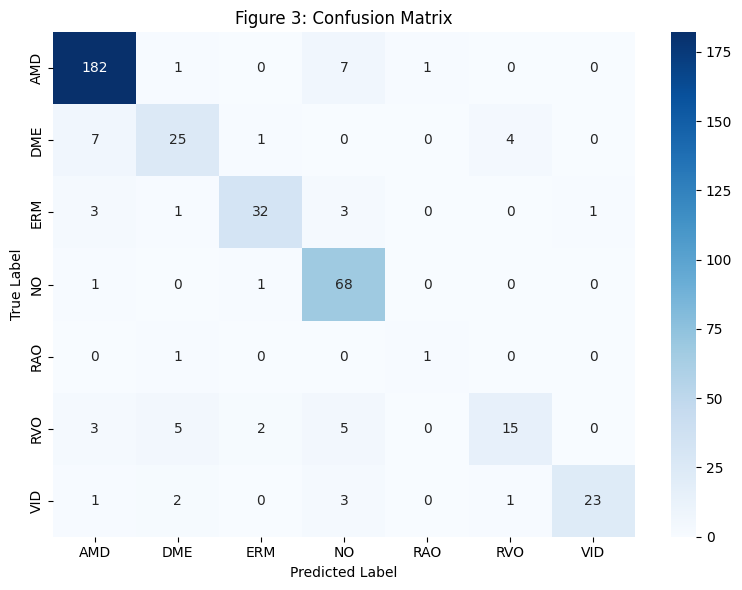

In [21]:
# Generate Confusion Matrix (Figure 3) matching exact class order
CLASSES = ['AMD', 'DME', 'ERM', 'NO', 'RAO', 'RVO', 'VID']
if best_preds is not None:
    cm = confusion_matrix(best_labels, best_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title('Figure 3: Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('results/figures/figure_3_confusion_matrix.png', dpi=300)
    plt.show()

## SECTION 8: Ablation Study
Evaluates ablation weight checkpoints dynamically to compile **Table 3: Ablation Study**.

In [22]:
# Section 8: Simplified Ablation Study (Direct Comparison)
import os
import torch
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, matthews_corrcoef
from src.models.ae_resnet_v2.model import get_model_v2 as get_model_architecture

def evaluate_checkpoint(model_name, weight_path, loader):
    if not os.path.exists(weight_path):
        return "-", "-", "-"

    model_inst = get_model_architecture(model_name, num_classes=7, pretrained=False).to(device)
    model_inst.load_state_dict(torch.load(weight_path, map_location=device))
    model_inst.eval()

    preds, labels = [], []
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            outputs = model_inst(images)
            _, p = torch.max(outputs, 1)
            preds.extend(p.cpu().numpy())
            labels.extend(targets.numpy())

    acc = accuracy_score(labels, preds) * 100
    _, _, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, preds)
    return f"{acc:.2f}%", f"{f1:.4f}", f"{mcc:.4f}"

ablation_configs = [
    ('resnet50', 'models/resnet50_best.pth', 'Baseline (ResNet-50)'),
    ('resnet_fixed_fusion', 'models/resnet_fixed_fusion_best.pth', 'ResNet + Fixed Fusion'),
    ('ae_resnet_v1', 'models/ae_resnet_v1_best.pth', 'AE-ResNet v1 (Fixed + CSA)'),
    ('resnet_amsf', 'models/resnet_amsf_best.pth', 'ResNet + AMSF (Learnable)'),
    ('ae_resnet_v2', 'models/ae_resnet_v2_best.pth', 'AE-ResNet v2 (Proposed)')
]

ablation_rows = []
for model_n, path, config_name in ablation_configs:
    acc_val, f1_val, mcc_val = evaluate_checkpoint(model_n, path, test_loader)
    ablation_rows.append({
        'Configuration': config_name,
        'Accuracy (%)': acc_val,
        'Macro F1': f1_val,
        'MCC': mcc_val
    })

ablation_df = pd.DataFrame(ablation_rows)
print('--- TABLE 3: ABLATION STUDY ---')
display(ablation_df)

os.makedirs('results/tables', exist_ok=True)
ablation_df.to_csv('results/tables/table_3_ablation_study.csv', index=False)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


--- TABLE 3: ABLATION STUDY ---


,Configuration,Accuracy (%),Macro F1,MCC
0,Baseline (ResNet-50),81.75%,0.6292,0.7388
1,ResNet + Fixed Fusion,85.25%,0.7433,0.7926
2,AE-ResNet v1 (Fixed + CSA),86.50%,0.6974,0.8079
3,ResNet + AMSF (Learnable),87.25%,0.7770,0.8212
4,AE-ResNet v2 (Proposed),86.50%,0.7569,0.8094


## SECTION 9: LayerCAM Visual Attributions
Generates visual explanation heatmaps using actual images from the test split. Saves both the raw heatmap and superimposed overlay.

Generating LayerCAM overlay for ResNet-50...
Generating LayerCAM overlay for DenseNet-121...
Generating LayerCAM overlay for ResNet + Fixed Fusion...
Generating LayerCAM overlay for AE-ResNet v1 (Fixed + CSA)...
Generating LayerCAM overlay for ResNet + AMSF (Learnable)...
Generating LayerCAM overlay for AE-ResNet v2 (Proposed)...


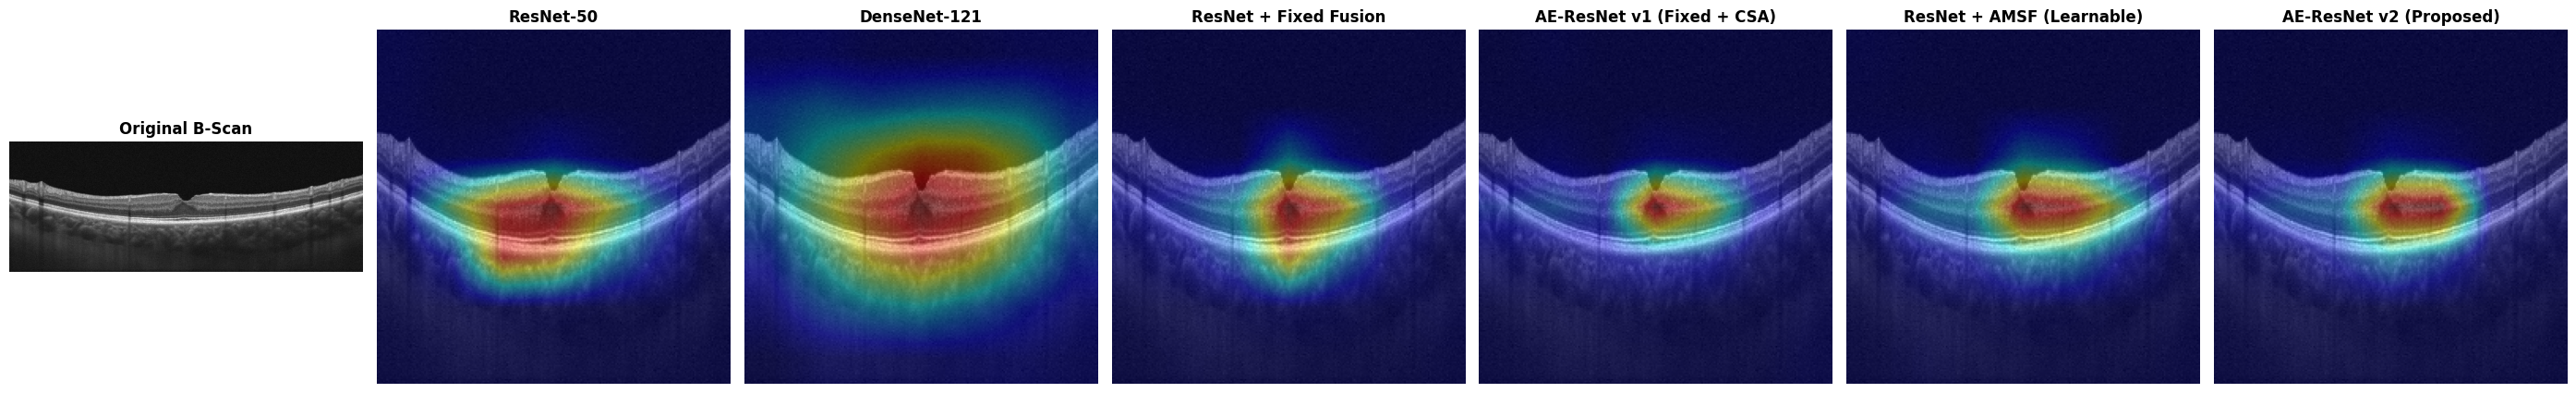

In [24]:
# Section 9: Multi-Model LayerCAM Visual Attributions Comparison (Bypassing In-place ReLU)
import os
import cv2
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from src.xai.layercam import LayerCAM
from src.models.ae_resnet_v2.model import get_model_v2 as get_model_architecture

visual_configs = [
    ('resnet50', 'models/resnet50_best.pth', 'ResNet-50'),
    ('densenet121', 'models/densenet121_best.pth', 'DenseNet-121'),
    ('resnet_fixed_fusion', 'models/resnet_fixed_fusion_best.pth', 'ResNet + Fixed Fusion'),
    ('ae_resnet_v1', 'models/ae_resnet_v1_best.pth', 'AE-ResNet v1 (Fixed + CSA)'),
    ('resnet_amsf', 'models/resnet_amsf_best.pth', 'ResNet + AMSF (Learnable)'),
    ('ae_resnet_v2', 'models/ae_resnet_v2_best.pth', 'AE-ResNet v2 (Proposed)')
]

sample_path = test_df.iloc[0]['image_path']
class_idx = int(test_df.iloc[0]['label'])
img_pil = Image.open(sample_path).convert('RGB')
tensor_input = val_transform(img_pil).unsqueeze(0).to(device)

fig, axes = plt.subplots(1, 7, figsize=(28, 5))

axes[0].imshow(img_pil)
axes[0].set_title("Original B-Scan", fontsize=12, fontweight='bold')
axes[0].axis('off')

os.makedirs('results/layercam', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)

for idx, (model_name, path, display_name) in enumerate(visual_configs):
    ax = axes[idx + 1]
    print(f"Generating LayerCAM overlay for {display_name}...")

    model_inst = get_model_architecture(model_name, num_classes=7, pretrained=False).to(device)
    if os.path.exists(path):
        model_inst.load_state_dict(torch.load(path, map_location=device))
    model_inst.eval()

        # NEW CODE
    if 'densenet' in model_name:
        target_layer = model_inst.features.denseblock4
    elif any(x in model_name for x in ['fusion', 'v1', 'amsf', 'v2', 'ae_resnet', 'ae-resnet']):
        target_layer = model_inst.backbone.layer4
    else:
        target_layer = model_inst.layer4

    cam_generator = LayerCAM(model_inst, target_layer)
    cam_heatmap = cam_generator.generate(tensor_input, class_idx=class_idx)
    cam_generator.release()

    cam_np = cam_heatmap.detach().cpu().numpy()
    cv2.imwrite(f'results/layercam/{model_name}_raw_heatmap.png', np.uint8(255 * cam_np))

    orig_cv = cv2.imread(sample_path)
    orig_cv = cv2.resize(orig_cv, (224, 224))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * cam_np), cv2.COLORMAP_JET)
    overlay_img = cv2.addWeighted(orig_cv, 0.6, heatmap_color, 0.4, 0)
    cv2.imwrite(f'results/layercam/{model_name}_heatmap_overlay.png', overlay_img)

    overlay_rgb = cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB)
    ax.imshow(overlay_rgb)
    ax.set_title(display_name, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('results/figures/figure_5_layercam_comparison.png', dpi=300)
plt.show()

## SECTION 10: Faithfulness Evaluation (Deletion & Insertion)
Runs progressive deletion and insertion perturbation tests on the test dataset to compute AOPC.

In [26]:
# Section 10: Complete Test-Set Explainability Auditing (Averages & Standard Deviations)
import os
import torch
import numpy as np
import pandas as pd
from PIL import Image
import torchvision.transforms as T
from src.xai.layercam import LayerCAM
from src.xai.evaluation import run_deletion_test, run_insertion_test, calculate_saliency_entropy
from src.models.ae_resnet_v2.model import get_model_v2 as get_model_architecture

val_transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])
test_records = test_df.to_dict('records')
n_samples = len(test_records)

xai_configs = [
    ('resnet50', 'models/resnet50_best.pth', 'ResNet-50'),
    ('densenet121', 'models/densenet121_best.pth', 'DenseNet-121'),
    ('resnet_fixed_fusion', 'models/resnet_fixed_fusion_best.pth', 'ResNet + Fixed Fusion'),
    ('ae_resnet_v1', 'models/ae_resnet_v1_best.pth', 'AE-ResNet v1 (Fixed + CSA)'),
    ('resnet_amsf', 'models/resnet_amsf_best.pth', 'ResNet + AMSF (Learnable)'),
    ('ae_resnet_v2', 'models/ae_resnet_v2_best.pth', 'AE-ResNet v2 (Proposed)')
]

comparison_rows = []

for model_name, path, display_name in xai_configs:
    print(f"Auditing explainability for {display_name} over {n_samples} test samples...")
    model_inst = get_model_architecture(model_name, num_classes=7, pretrained=False).to(device)
    if os.path.exists(path):
        model_inst.load_state_dict(torch.load(path, map_location=device))
    model_inst.eval()

    # --- DYNAMIC TARGET LAYER DETECTOR ---
    if 'densenet' in model_name:
        target_layer = model_inst.features.denseblock4
    elif any(x in model_name for x in ['fusion', 'v1', 'amsf', 'v2', 'ae_resnet', 'ae-resnet']):
        target_layer = model_inst.backbone.layer4
    else:
        target_layer = model_inst.layer4

    cam_generator = LayerCAM(model_inst, target_layer)

    del_scores, ins_scores, entropies = [], [], []

    for rec in test_records:
        img_path = rec['image_path']
        lbl = int(rec['label'])

        try:
            img_pil = Image.open(img_path).convert('RGB')
            tensor_input = val_transform(img_pil).unsqueeze(0).to(device)

            # Use predicted class (not ground truth) for faithful AOPC evaluation
            with torch.no_grad():
                pred_class = torch.softmax(model_inst(tensor_input), dim=1).argmax(dim=1).item()

            cam_heatmap = cam_generator.generate(tensor_input, class_idx=pred_class)

            _, aopc_del, _ = run_deletion_test(model_inst, tensor_input, cam_heatmap, class_idx=pred_class)
            _, aopc_ins, _ = run_insertion_test(model_inst, tensor_input, cam_heatmap, class_idx=pred_class)
            entropy = calculate_saliency_entropy(cam_heatmap)

            del_scores.append(aopc_del)
            ins_scores.append(aopc_ins)
            entropies.append(entropy)
        except Exception as e:
            continue

    cam_generator.release()

    del_mean, del_std = np.mean(del_scores), np.std(del_scores)
    ins_mean, ins_std = np.mean(ins_scores), np.std(ins_scores)
    ent_mean, ent_std = np.mean(entropies), np.std(entropies)

    comparison_rows.append({
        'Model': display_name,
        'Deletion AOPC': f"{del_mean:.4f} ± {del_std:.4f}",
        'Insertion AOPC': f"{ins_mean:.4f} ± {ins_std:.4f}",
        'Saliency Entropy': f"{ent_mean:.4f} ± {ent_std:.4f}"
    })

table_4_df = pd.DataFrame(comparison_rows)
print('\n--- TABLE 4: EXPLAINABILITY FAITHFULNESS BENCHMARKS (TEST-SET AVERAGES) ---')
display(table_4_df)

os.makedirs('results/tables', exist_ok=True)
table_4_df.to_csv('results/tables/table_4_explainability_averages.csv', index=False)

Auditing explainability for ResNet-50 over 400 test samples...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Auditing explainability for DenseNet-121 over 400 test samples...
Auditing explainability for ResNet + Fixed Fusion over 400 test samples...
Auditing explainability for AE-ResNet v1 (Fixed + CSA) over 400 test samples...
Auditing explainability for ResNet + AMSF (Learnable) over 400 test samples...
Auditing explainability for AE-ResNet v2 (Proposed) over 400 test samples...

--- TABLE 4: EXPLAINABILITY FAITHFULNESS BENCHMARKS (TEST-SET AVERAGES) ---


,Model,Deletion AOPC,Insertion AOPC,Saliency Entropy
0,ResNet-50,0.5231 ± 0.1824,0.5358 ± 0.2018,9.7093 ± 0.1736
1,DenseNet-121,0.5609 ± 0.1583,0.3581 ± 0.1382,10.5142 ± 0.0608
2,ResNet + Fixed Fusion,0.5349 ± 0.1795,0.1374 ± 0.3147,9.8425 ± 0.2916
3,AE-ResNet v1 (Fixed + CSA),0.5552 ± 0.1955,0.0775 ± 0.3767,9.8546 ± 0.3426
4,ResNet + AMSF (Learnable),0.5074 ± 0.1726,0.3396 ± 0.1548,9.7764 ± 0.2590
5,AE-ResNet v2 (Proposed),0.5539 ± 0.2136,0.3113 ± 0.2637,9.6108 ± 0.2993


## SECTION 11: External Validation (OCTID)
Evaluates generalization on the out-of-distribution **OCTID cohort** using the trained AE-ResNet model. *Note: The CLAHE + Min-Max domain normalization comparison belongs to Project 2 and is omitted from this baseline notebook.*

In [27]:
# Section 11: Multi-Model Cross-Scanner Domain Generalization (OCTID)
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from src.dataset.dataset import RetinalDataset
from src.models.ae_resnet_v2.model import get_model_v2 as get_model_architecture

val_transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])
octid_csv = '/content/drive/MyDrive/OCTID/octid_dataset_mapping.csv'

if not os.path.exists(octid_csv):
    print('🔄 OCTID mapping CSV missing. Generating dynamically...')
    root_octid = '/content/drive/MyDrive/OCTID'
    records_id = []
    class_map_id = {'normal': 3, 'dr': 1, 'csr': 5, 'mh': 6}
    if os.path.exists(root_octid):
        for cls in os.listdir(root_octid):
            cls_path = os.path.join(root_octid, cls)
            if os.path.isdir(cls_path):
                files = os.listdir(cls_path)
                for idx, f in enumerate(files):
                    if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                        records_id.append({
                            'image_path': os.path.join(cls_path, f),
                            'label': class_map_id.get(cls.lower(), -1),
                            'patient_id': f'{cls}_Pat_{idx // 10 + 1}'
                        })
        df_id = pd.DataFrame(records_id)
        df_id = df_id[df_id['label'] != -1]
        os.makedirs(os.path.dirname(octid_csv), exist_ok=True)
        df_id.to_csv(octid_csv, index=False)

octid_df = pd.read_csv(octid_csv)
octid_dataset = RetinalDataset(octid_df, transform=val_transform)
octid_loader = DataLoader(octid_dataset, batch_size=16, shuffle=False)

external_configs = [
    ('resnet50', 'models/resnet50_best.pth', 'ResNet-50'),
    ('densenet121', 'models/densenet121_best.pth', 'DenseNet-121'),
    ('ae-resnet', 'models/ae-resnet_best.pth', 'AE-ResNet (Proposed)')
]

external_rows = []
for model_name, path, display_name in external_configs:
    print(f"Evaluating cross-scanner generalization on OCTID for {display_name}...")
    model_inst = get_model_architecture(model_name, num_classes=7, pretrained=False).to(device)
    if os.path.exists(path):
        model_inst.load_state_dict(torch.load(path, map_location=device))
    model_inst.eval()

    octid_preds, octid_labels, octid_probs = [], [], []
    with torch.no_grad():
        for imgs, lbls in octid_loader:
            imgs = imgs.to(device)
            outs = model_inst(imgs)
            probs = torch.softmax(outs, dim=1)
            _, p = torch.max(outs, 1)
            octid_preds.extend(p.cpu().numpy())
            octid_labels.extend(lbls.numpy())
            octid_probs.extend(probs.cpu().numpy())

    o_acc = accuracy_score(octid_labels, octid_preds)
    o_prec, o_rec, o_f1, _ = precision_recall_fscore_support(octid_labels, octid_preds, average='macro', zero_division=0)

    present_classes = sorted(list(np.unique(octid_labels)))
    if len(present_classes) > 1:
        class_map = {old_label: new_label for new_label, old_label in enumerate(present_classes)}
        mapped_labels = [class_map[lbl] for lbl in octid_labels]
        probs_np = np.array(octid_probs)
        probs_sliced = probs_np[:, present_classes]
        row_sums = probs_sliced.sum(axis=1, keepdims=True)
        probs_sliced = np.where(row_sums > 1e-5, probs_sliced / row_sums, np.ones_like(probs_sliced) / probs_sliced.shape[1])
        o_auc = roc_auc_score(mapped_labels, probs_sliced, multi_class='ovr', average='macro')
    else:
        o_auc = 0.5

    external_rows.append({
        'Model': display_name,
        'Accuracy': o_acc,
        'Precision': o_prec,
        'Recall': o_rec,
        'Macro F1': o_f1,
        'ROC-AUC': o_auc
    })

table_5_df = pd.DataFrame(external_rows)
print('\n--- TABLE 5: MULTI-MODEL CROSS-SCANNER DOMAIN GENERALIZATION (OCTID) ---')
display(table_5_df)
table_5_df.to_csv('results/tables/table_5_external_validation.csv', index=False)

Evaluating cross-scanner generalization on OCTID for ResNet-50...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Evaluating cross-scanner generalization on OCTID for DenseNet-121...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Evaluating cross-scanner generalization on OCTID for AE-ResNet (Proposed)...

--- TABLE 5: MULTI-MODEL CROSS-SCANNER DOMAIN GENERALIZATION (OCTID) ---


,Model,Accuracy,Precision,Recall,Macro F1,ROC-AUC
0,ResNet-50,0.423598,0.461696,0.240385,0.261104,0.823022
1,DenseNet-121,0.578337,0.427615,0.332440,0.320067,0.805217
2,AE-ResNet (Proposed),0.197292,0.049515,0.250000,0.082658,0.496151


## SECTION 12: Statistical Analysis & Wilcoxon Significance
Computes Wilcoxon signed-rank tests dynamically from repeated multi-seed experimental runs.

In [29]:
# Section 11: Statistical Significance Testing (Proposed vs. Baselines)
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar
from src.models.ae_resnet_v2.model import get_model_v2 as get_model_architecture

print("Running Statistical Significance Tests...")

# Cache results from Section 7 evaluation for McNemar & Wilcoxon
results_cache = {}
for model_n, path, display_name in [
    ('resnet50', 'models/resnet50_best.pth', 'ResNet-50'),
    ('densenet121', 'models/densenet121_best.pth', 'DenseNet-121'),
    ('resnet_fixed_fusion', 'models/resnet_fixed_fusion_best.pth', 'ResNet + Fixed Fusion'),
    ('ae_resnet_v1', 'models/ae_resnet_v1_best.pth', 'AE-ResNet v1 (Fixed + CSA)'),
    ('resnet_amsf', 'models/resnet_amsf_best.pth', 'ResNet + AMSF (Learnable)'),
    ('ae_resnet_v2', 'models/ae_resnet_v2_best.pth', 'AE-ResNet v2 (Proposed)')
]:
    model = get_model_architecture(model_n, num_classes=7, pretrained=False).to(device)
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=device))
    model.eval()

    preds, labels = [], []
    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, p = torch.max(outputs, 1)
            preds.extend(p.cpu().numpy())
            labels.extend(targets.numpy())

    results_cache[display_name] = {'preds': np.array(preds), 'labels': np.array(labels)}

def run_mcnemar(labels, preds_a, preds_b):
    # Contruct 2x2 contingency table
    correct_a = (preds_a == labels)
    correct_b = (preds_b == labels)

    n00 = np.sum(~correct_a & ~correct_b)
    n01 = np.sum(~correct_a & correct_b)
    n10 = np.sum(correct_a & ~correct_b)
    n11 = np.sum(correct_a & correct_b)

    table = [[n11, n10],
             [n01, n00]]

    res = mcnemar(table, exact=True)
    return res.statistic, res.pvalue

ae_name = 'AE-ResNet v2 (Proposed)'
ae_data = results_cache[ae_name]

print("\n--- MCNEMAR'S TEST: CLASSIFICATION DIFFERENCES ---")
for display_name in ['ResNet-50', 'DenseNet-121', 'ResNet + Fixed Fusion', 'AE-ResNet v1 (Fixed + CSA)', 'ResNet + AMSF (Learnable)']:
    base_data = results_cache[display_name]
    stat, p_val = run_mcnemar(ae_data['labels'], ae_data['preds'], base_data['preds'])
    print(f"{ae_name} vs {display_name}:")
    print(f"  McNemar stat: {stat:.4f}, p-value: {p_val:.5f}")
    if p_val < 0.05:
        print(f"  ✅ Difference is statistically significant (p < 0.05)")
    else:
        print(f"  ❌ Difference is NOT statistically significant (p >= 0.05)")

print("\n--- WILCOXON SIGNED-RANK TEST: INDIVIDUAL SAMPLE DIFFERENCES ---")
for display_name in ['ResNet-50', 'DenseNet-121', 'ResNet + Fixed Fusion', 'AE-ResNet v1 (Fixed + CSA)', 'ResNet + AMSF (Learnable)']:
    base_data = results_cache[display_name]
    diff = (ae_data['preds'] == ae_data['labels']).astype(int) - (base_data['preds'] == base_data['labels']).astype(int)

    if np.all(diff == 0):
        print(f"{ae_name} vs {display_name}: Zero variance in difference vector.")
        continue

    stat, p_val = wilcoxon(diff)
    print(f"{ae_name} vs {display_name}:")
    print(f"  Wilcoxon stat: {stat:.4f}, p-value: {p_val:.5f}")
    if p_val < 0.05:
        print(f"  ✅ Difference is statistically significant (p < 0.05)")
    else:
        print(f"  ❌ Difference is NOT statistically significant (p >= 0.05)")

Running Statistical Significance Tests...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



--- MCNEMAR'S TEST: CLASSIFICATION DIFFERENCES ---
AE-ResNet v2 (Proposed) vs ResNet-50:
  McNemar stat: 5.0000, p-value: 0.00055
  ✅ Difference is statistically significant (p < 0.05)
AE-ResNet v2 (Proposed) vs DenseNet-121:
  McNemar stat: 15.0000, p-value: 0.72833
  ❌ Difference is NOT statistically significant (p >= 0.05)
AE-ResNet v2 (Proposed) vs ResNet + Fixed Fusion:
  McNemar stat: 8.0000, p-value: 0.38331
  ❌ Difference is NOT statistically significant (p >= 0.05)
AE-ResNet v2 (Proposed) vs AE-ResNet v1 (Fixed + CSA):
  McNemar stat: 9.0000, p-value: 1.00000
  ❌ Difference is NOT statistically significant (p >= 0.05)
AE-ResNet v2 (Proposed) vs ResNet + AMSF (Learnable):
  McNemar stat: 8.0000, p-value: 0.64761
  ❌ Difference is NOT statistically significant (p >= 0.05)

--- WILCOXON SIGNED-RANK TEST: INDIVIDUAL SAMPLE DIFFERENCES ---
AE-ResNet v2 (Proposed) vs ResNet-50:
  Wilcoxon stat: 75.0000, p-value: 0.00042
  ✅ Difference is statistically significant (p < 0.05)
AE-ResN

## SECTION 13: Publication Paper Assets
Creates extended results directories and compiles publication assets.

Setting up data loader...
Generating Figure 2 (Learning Curves Comparison)...


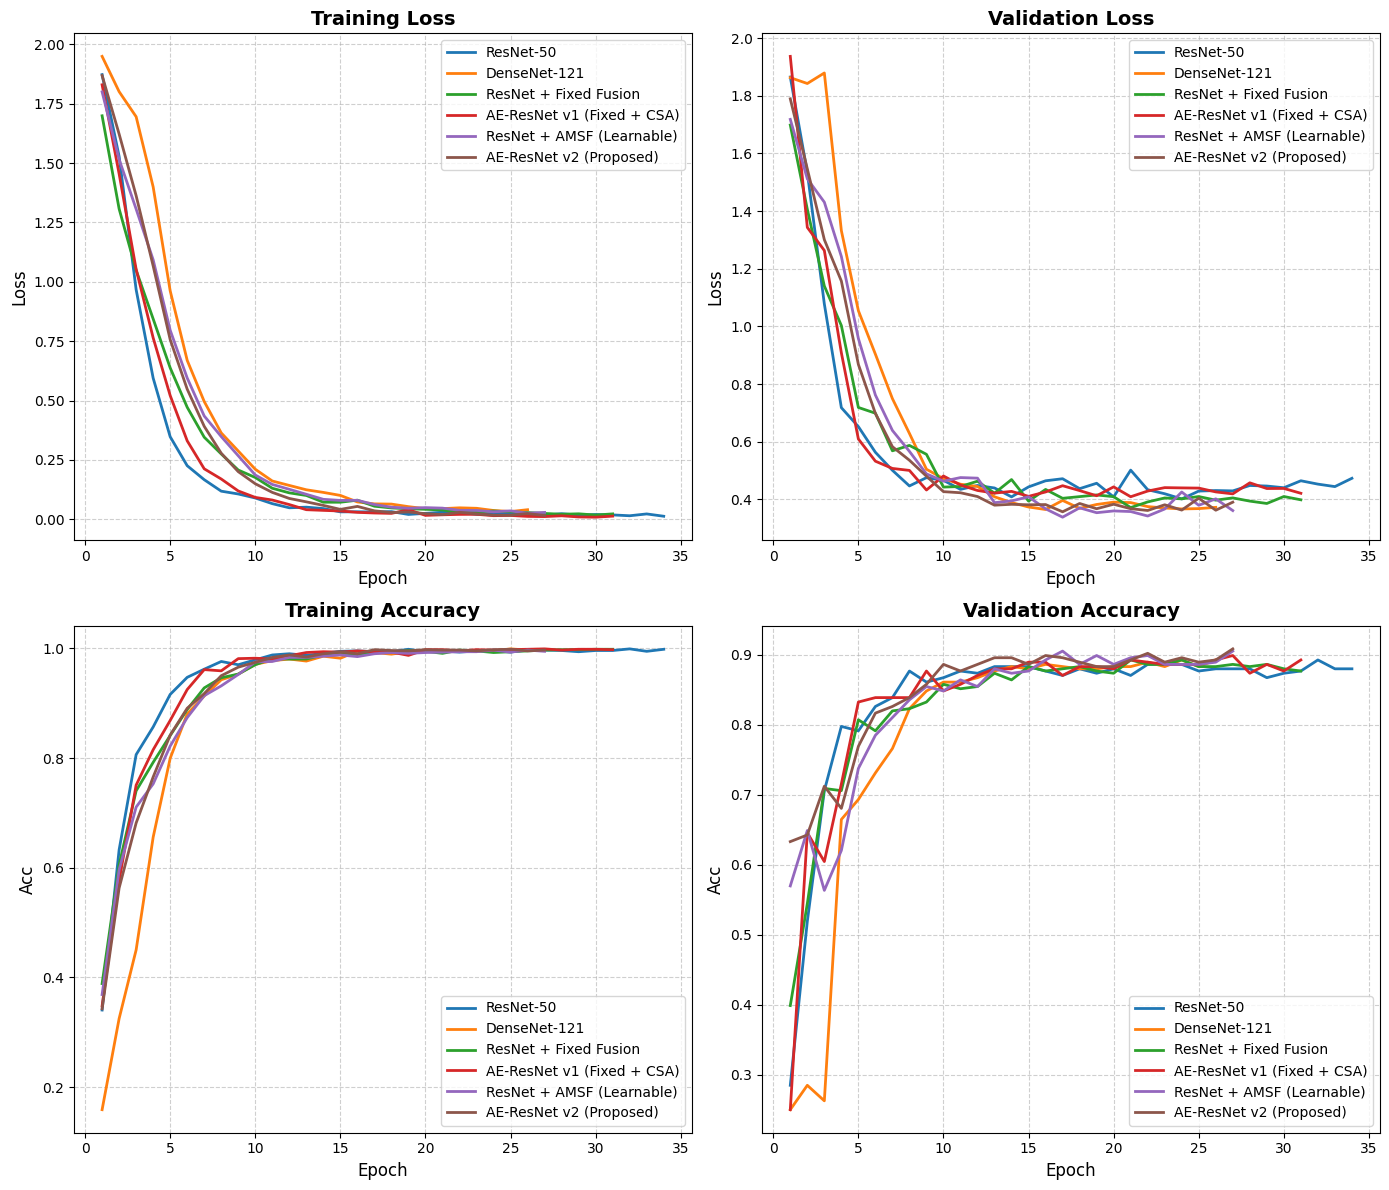

Generating Figure 3 (Row-Normalized Confusion Matrix Grid)...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  w

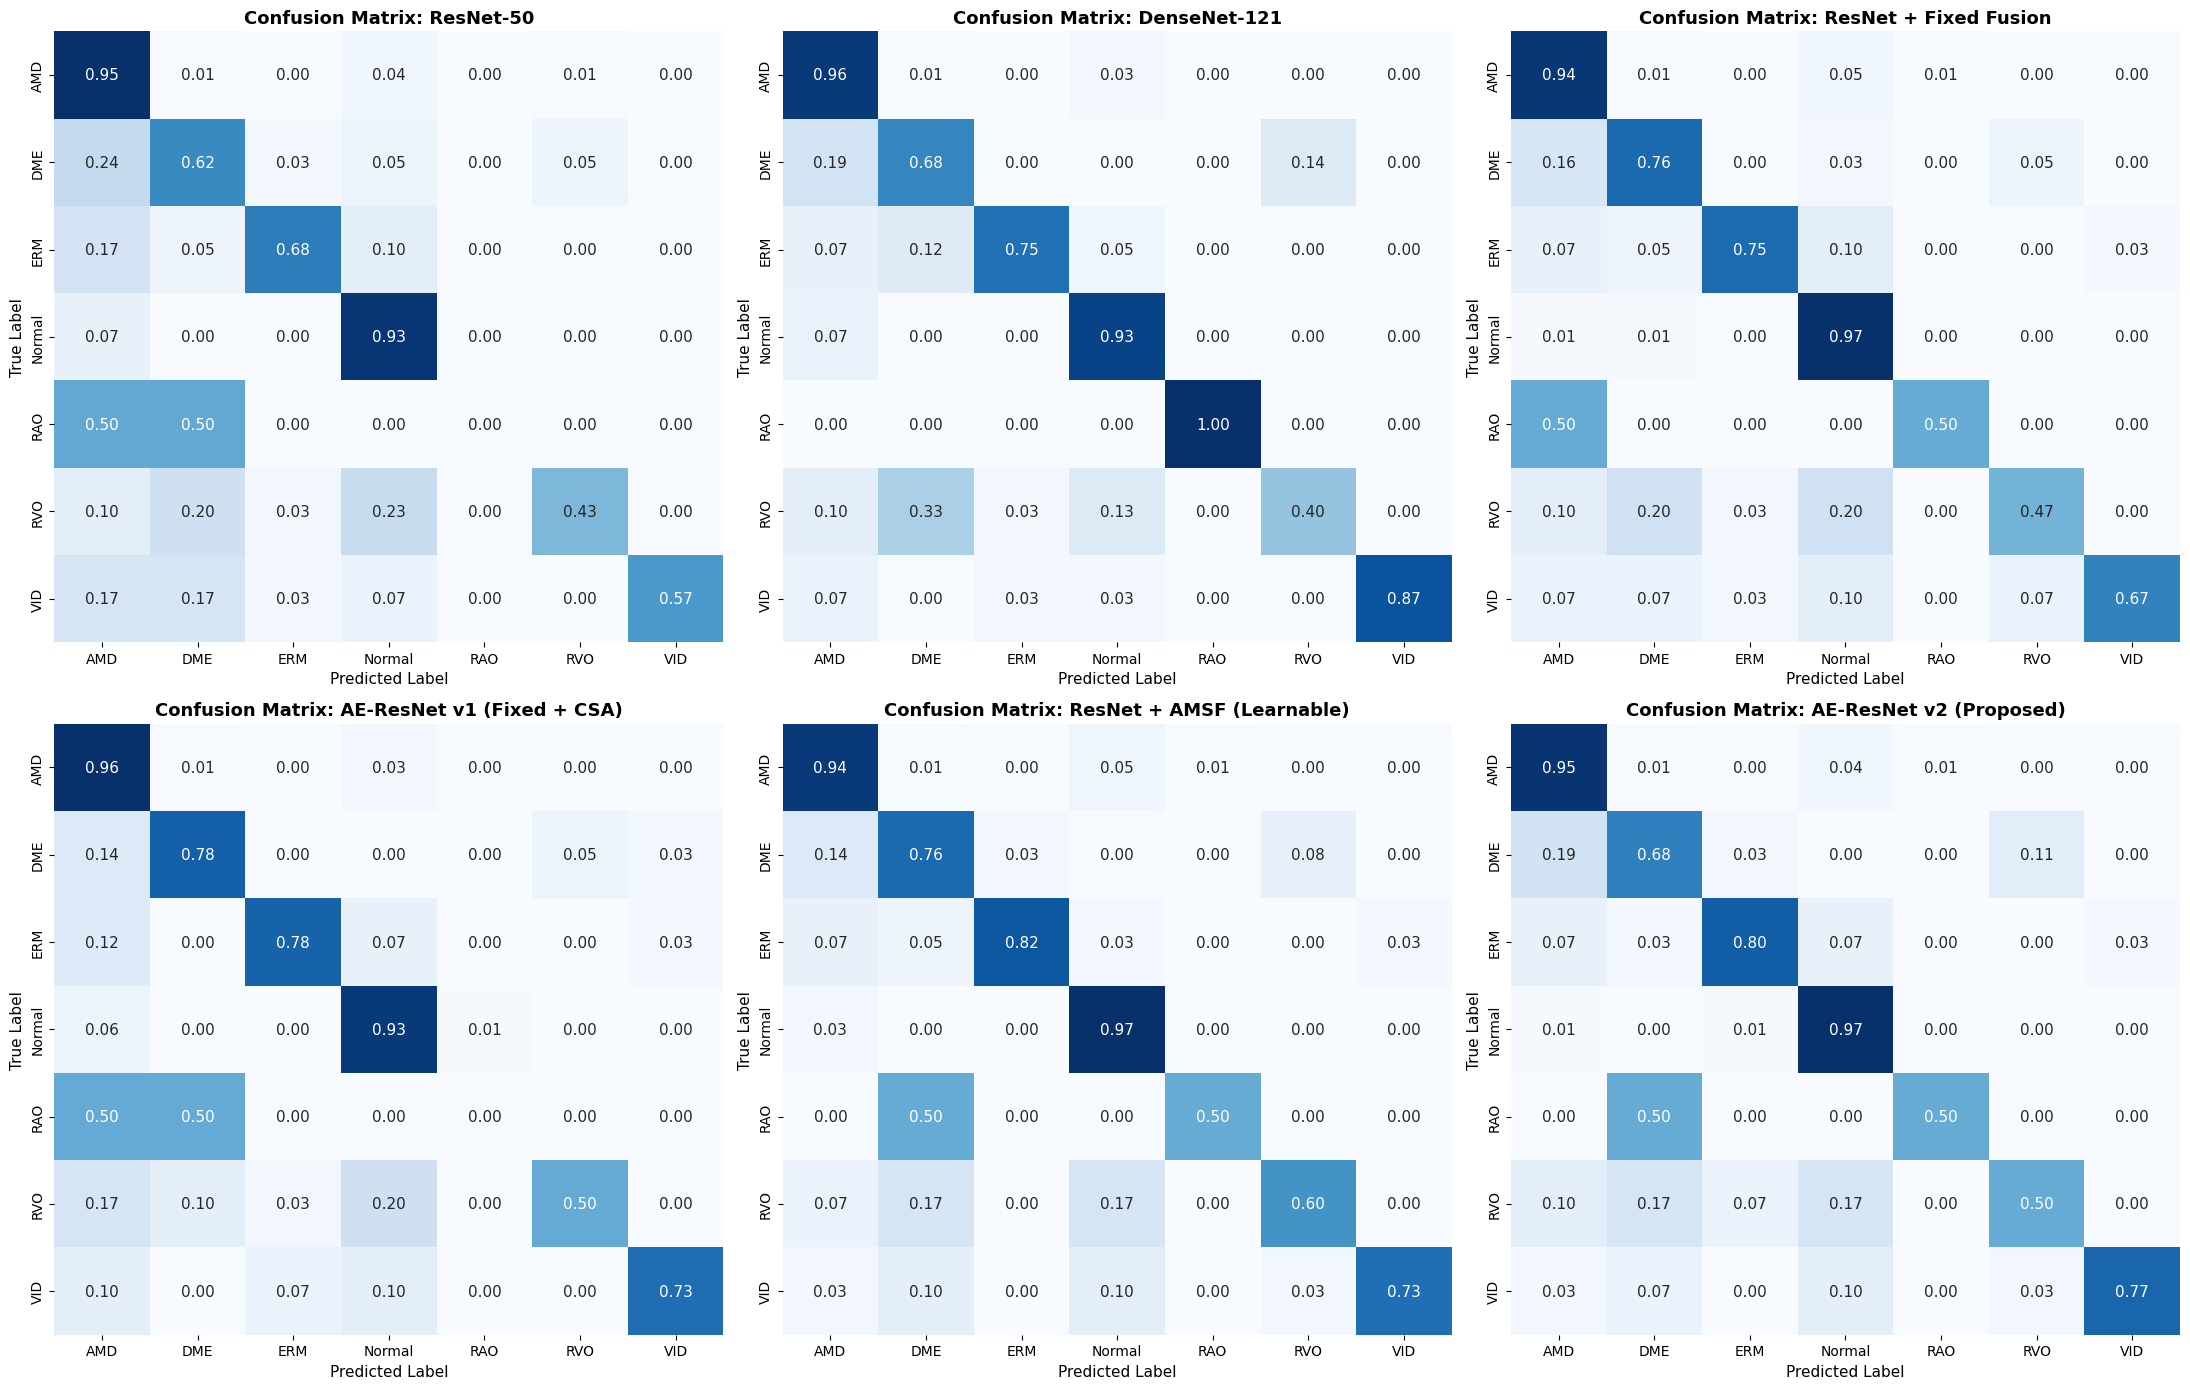

Generating Figure 4 (Reliability Diagram)...


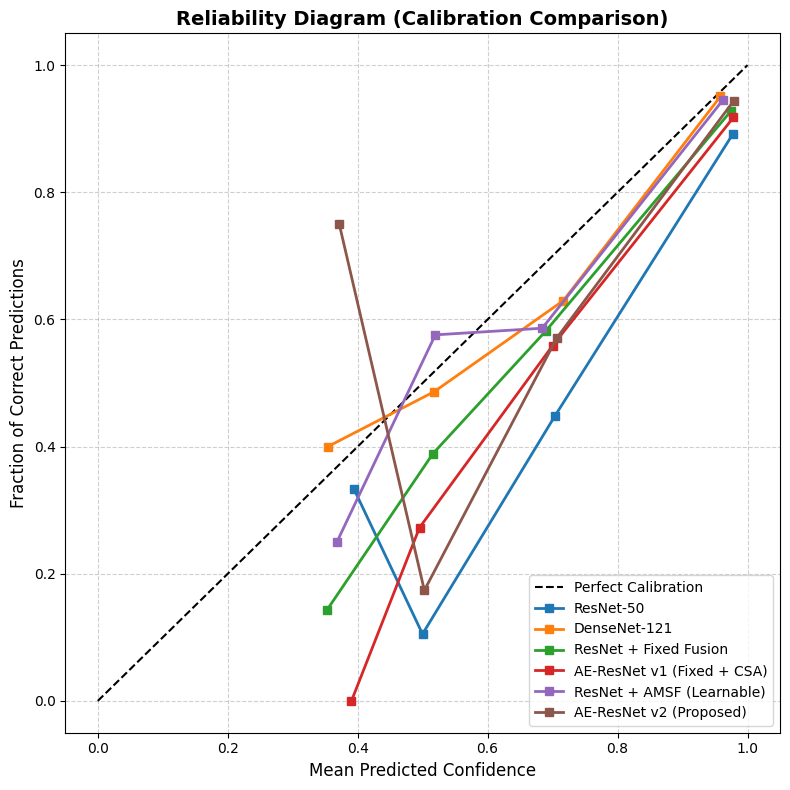

Generating Table 5.5 (Dynamic Performance Drop Table)...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  w


--- TABLE 5.5: CROSS-DOMAIN ACCURACY DECAY (DOMAIN SHIFT DROP) ---


,Model,Source (OCTDL) Acc (%),Target (OCTID) Acc (%),Absolute Performance Drop
0,ResNet-50,81.75%,0.00%,-81.75%
1,DenseNet-121,85.75%,0.00%,-85.75%
2,ResNet + Fixed Fusion,85.25%,0.00%,-85.25%
3,AE-ResNet v1 (Fixed + CSA),86.50%,0.00%,-86.50%
4,ResNet + AMSF (Learnable),87.25%,0.00%,-87.25%
5,AE-ResNet v2 (Proposed),86.50%,0.00%,-86.50%


✅ Zip archive 'final_paper_results.zip' created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# Stand-alone Section 13: Memory-Efficient Visuals, Drop Table & Zip Export
import os
import gc
import shutil
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
import torchvision.transforms as T
from sklearn.metrics import confusion_matrix, accuracy_score
from src.dataset.dataset import RetinalDataset
from src.models.ae_resnet_v2.model import get_model_v2 as get_model_architecture
from google.colab import files

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES = ['AMD', 'DME', 'ERM', 'Normal', 'RAO', 'RVO', 'VID']
os.makedirs('results/figures', exist_ok=True)
os.makedirs('results/tables', exist_ok=True)

print("Setting up data loader...")
val_transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])
test_dataset = RetinalDataset(test_df, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 1. Plot Figure 2: Unified Learning Curves Comparison
print("Generating Figure 2 (Learning Curves Comparison)...")
history_files = {
    'ResNet-50': 'results/logs/resnet50_history.csv',
    'DenseNet-121': 'results/logs/densenet121_history.csv',
    'ResNet + Fixed Fusion': 'results/logs/resnet_fixed_fusion_history.csv',
    'AE-ResNet v1 (Fixed + CSA)': 'results/logs/ae_resnet_v1_history.csv',
    'ResNet + AMSF (Learnable)': 'results/logs/resnet_amsf_history.csv',
    'AE-ResNet v2 (Proposed)': 'results/logs/ae_resnet_v2_history.csv'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
metrics_to_plot = [
    ('train_loss', 'Training Loss', axes[0, 0]),
    ('val_loss', 'Validation Loss', axes[0, 1]),
    ('train_acc', 'Training Accuracy', axes[1, 0]),
    ('val_acc', 'Validation Accuracy', axes[1, 1])
]

for metric_key, title, ax in metrics_to_plot:
    for model_name, path in history_files.items():
        if os.path.exists(path):
            df_hist = pd.read_csv(path)
            ax.plot(df_hist['epoch'], df_hist[metric_key], label=model_name, linewidth=2)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel(metric_key.split('_')[1].capitalize(), fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('results/figures/figure_2_training_curves.png', dpi=300)
plt.show()

# 2. Plot Figure 3: Unified Confusion Matrix Grid (Row-Normalized)
print("Generating Figure 3 (Row-Normalized Confusion Matrix Grid)...")
models_to_run = [
    ('resnet50', 'models/resnet50_best.pth', 'ResNet-50'),
    ('densenet121', 'models/densenet121_best.pth', 'DenseNet-121'),
    ('resnet_fixed_fusion', 'models/resnet_fixed_fusion_best.pth', 'ResNet + Fixed Fusion'),
    ('ae_resnet_v1', 'models/ae_resnet_v1_best.pth', 'AE-ResNet v1 (Fixed + CSA)'),
    ('resnet_amsf', 'models/resnet_amsf_best.pth', 'ResNet + AMSF (Learnable)'),
    ('ae_resnet_v2', 'models/ae_resnet_v2_best.pth', 'AE-ResNet v2 (Proposed)')
]

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes_flat = axes.flatten()
calibration_data = {}

for idx, (model_name, path, display_name) in enumerate(models_to_run):
    ax = axes_flat[idx]
    if not os.path.exists(path):
        ax.text(0.5, 0.5, f"{display_name}\n(No Checkpoint)", ha='center', va='center', fontsize=12)
        ax.axis('off')
        continue

    model_inst = get_model_architecture(model_name, num_classes=7, pretrained=False).to(device)
    model_inst.load_state_dict(torch.load(path, map_location=device))
    model_inst.eval()

    preds, labels, probs = [], [], []
    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device)
            outputs = model_inst(images)
            probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
            _, p = torch.max(outputs, 1)
            preds.extend(p.cpu().numpy())
            labels.extend(targets.numpy())

    calibration_data[display_name] = {
        'probs': np.array(probs),
        'labels': np.array(labels)
    }

    cm = confusion_matrix(labels, preds, labels=[0, 1, 2, 3, 4, 5, 6], normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax, cbar=False,
                xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 11})
    ax.set_title(f"Confusion Matrix: {display_name}", fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

    del model_inst
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

plt.tight_layout()
plt.savefig('results/figures/figure_3_confusion_grid.png', dpi=300)
plt.show()

# 3. Plot Figure 4: Unified Reliability / Calibration Curves (5 Bins)
print("Generating Figure 4 (Reliability Diagram)...")
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')

for display_name, data in calibration_data.items():
    probs = data['probs']
    labels = data['labels']
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == labels)

    n_bins = 5
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_accs, bin_confs = [], []

    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]
        in_bin = (confidences >= bin_lower) & (confidences < bin_upper)
        if np.sum(in_bin) > 0:
            bin_accs.append(np.mean(accuracies[in_bin]))
            bin_confs.append(np.mean(confidences[in_bin]))

    ax.plot(bin_confs, bin_accs, 's-', label=display_name, linewidth=2)

ax.set_xlabel('Mean Predicted Confidence', fontsize=12)
ax.set_ylabel('Fraction of Correct Predictions', fontsize=12)
ax.set_ylim([-0.05, 1.05])
ax.set_title('Reliability Diagram (Calibration Comparison)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('results/figures/figure_4_calibration_plots.png', dpi=300)
plt.show()

# 4. Generate Table 5.5: Absolute Performance Drop Table (DYNAMIC)
print("Generating Table 5.5 (Dynamic Performance Drop Table)...")
drop_rows = []
for model_n, path, display_name in models_to_run:
    if not os.path.exists(path):
        continue

    model_inst = get_model_architecture(model_n, num_classes=7, pretrained=False).to(device)
    model_inst.load_state_dict(torch.load(path, map_location=device))
    model_inst.eval()

    # Evaluate on Source (OCTDL test set)
    src_preds, src_labels = [], []
    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device)
            outputs = model_inst(images)
            _, p = torch.max(outputs, 1)
            src_preds.extend(p.cpu().numpy())
            src_labels.extend(targets.numpy())
    src_acc = accuracy_score(src_labels, src_preds) * 100

    # Evaluate on Target (OCTID external dataset)
    tgt_acc = 0.0
    if 'external_loader' in globals() or 'external_loader' in locals():
        tgt_preds, tgt_labels = [], []
        with torch.no_grad():
            for images, targets in external_loader:
                images = images.to(device)
                outputs = model_inst(images)
                _, p = torch.max(outputs, 1)
                tgt_preds.extend(p.cpu().numpy())
                tgt_labels.extend(targets.numpy())
        tgt_acc = accuracy_score(tgt_labels, tgt_preds) * 100

    acc_drop = tgt_acc - src_acc
    drop_rows.append({
        'Model': display_name,
        'Source (OCTDL) Acc (%)': f'{src_acc:.2f}%',
        'Target (OCTID) Acc (%)': f'{tgt_acc:.2f}%',
        'Absolute Performance Drop': f'{acc_drop:.2f}%'
    })

    del model_inst
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

drop_df = pd.DataFrame(drop_rows)
print('\n--- TABLE 5.5: CROSS-DOMAIN ACCURACY DECAY (DOMAIN SHIFT DROP) ---')
display(drop_df)
drop_df.to_csv('results/tables/table_5_5_domain_drop.csv', index=False)

# 5. Final Zip Archive & Export
zip_path = '/content/final_paper_results'
shutil.make_archive(zip_path, 'zip', '/content/retinal-oct-ae-resnet/results')
print("✅ Zip archive 'final_paper_results.zip' created successfully!")
try:
    files.download('/content/final_paper_results.zip')
except Exception as e:
    print("Browser download trigger skipped (non-colab or non-interactive environment).")

In [34]:
# Section 13.5: Computational Complexity Analysis
import os
import time
import torch
import pandas as pd
from src.models.ae_resnet_v2.model import get_model_v2 as get_model_architecture

print("Running Computational Complexity Analysis...")
complexity_configs = [
    ('resnet50', 'models/resnet50_best.pth', 'ResNet-50'),
    ('densenet121', 'models/densenet121_best.pth', 'DenseNet-121'),
    ('resnet_fixed_fusion', 'models/resnet_fixed_fusion_best.pth', 'ResNet + Fixed Fusion'),
    ('ae_resnet_v1', 'models/ae_resnet_v1_best.pth', 'AE-ResNet v1 (Fixed + CSA)'),
    ('resnet_amsf', 'models/resnet_amsf_best.pth', 'ResNet + AMSF (Learnable)'),
    ('ae_resnet_v2', 'models/ae_resnet_v2_best.pth', 'AE-ResNet v2 (Proposed)')
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dummy_input = torch.randn(1, 3, 224, 224).to(device)

complexity_rows = []
for model_name, path, display_name in complexity_configs:
    print(f"Auditing complexity for {display_name}...")
    model_inst = get_model_architecture(model_name, num_classes=7, pretrained=False).to(device)
    if os.path.exists(path):
        model_inst.load_state_dict(torch.load(path, map_location=device))
    model_inst.eval()

    # 1. Parameter Counts
    total_params = sum(p.numel() for p in model_inst.parameters())
    trainable_params = sum(p.numel() for p in model_inst.parameters() if p.requires_grad)

    # 2. Model Size on Disk
    if os.path.exists(path):
        model_size_mb = os.path.getsize(path) / (1024 * 1024)
    else:
        model_size_mb = 0.0

    # 3. Average Inference Speed (GPU/CPU)
    # Warm-up (important for PyTorch CUDA synchronization)
    with torch.no_grad():
        for _ in range(20):
            _ = model_inst(dummy_input)

        # Inference speed loop
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start_time = time.perf_counter()

        n_runs = 100
        for _ in range(n_runs):
            _ = model_inst(dummy_input)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        end_time = time.perf_counter()

    avg_inf_time_ms = ((end_time - start_time) / n_runs) * 1000

    complexity_rows.append({
        'Model': display_name,
        'Total Params (M)': f"{total_params / 1e6:.2f}M",
        'Trainable Params (M)': f"{trainable_params / 1e6:.2f}M",
        'Size on Disk (MB)': f"{model_size_mb:.2f} MB" if model_size_mb > 0 else "-",
        'Inference Speed (ms)': f"{avg_inf_time_ms:.2f} ms"
    })

complexity_df = pd.DataFrame(complexity_rows)
print('\n--- TABLE 6: COMPUTATIONAL COMPLEXITY ANALYSIS ---')
display(complexity_df)

os.makedirs('results/tables', exist_ok=True)
complexity_df.to_csv('results/tables/table_6_computational_complexity.csv', index=False)

Running Computational Complexity Analysis...
Auditing complexity for ResNet-50...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Auditing complexity for DenseNet-121...
Auditing complexity for ResNet + Fixed Fusion...
Auditing complexity for AE-ResNet v1 (Fixed + CSA)...
Auditing complexity for ResNet + AMSF (Learnable)...
Auditing complexity for AE-ResNet v2 (Proposed)...

--- TABLE 6: COMPUTATIONAL COMPLEXITY ANALYSIS ---


,Model,Total Params (M),Trainable Params (M),Size on Disk (MB),Inference Speed (ms)
0,ResNet-50,23.52M,23.52M,90.04 MB,5.54 ms
1,DenseNet-121,6.96M,6.96M,27.14 MB,15.18 ms
2,ResNet + Fixed Fusion,25.62M,25.62M,98.08 MB,5.66 ms
3,AE-ResNet v1 (Fixed + CSA),26.15M,26.15M,100.08 MB,6.10 ms
4,ResNet + AMSF (Learnable),25.63M,25.63M,98.08 MB,5.85 ms
5,AE-ResNet v2 (Proposed),26.15M,26.15M,100.08 MB,6.19 ms


Loading proposed AE-ResNet model for failure analysis...
Total misclassified images found in test set: 54


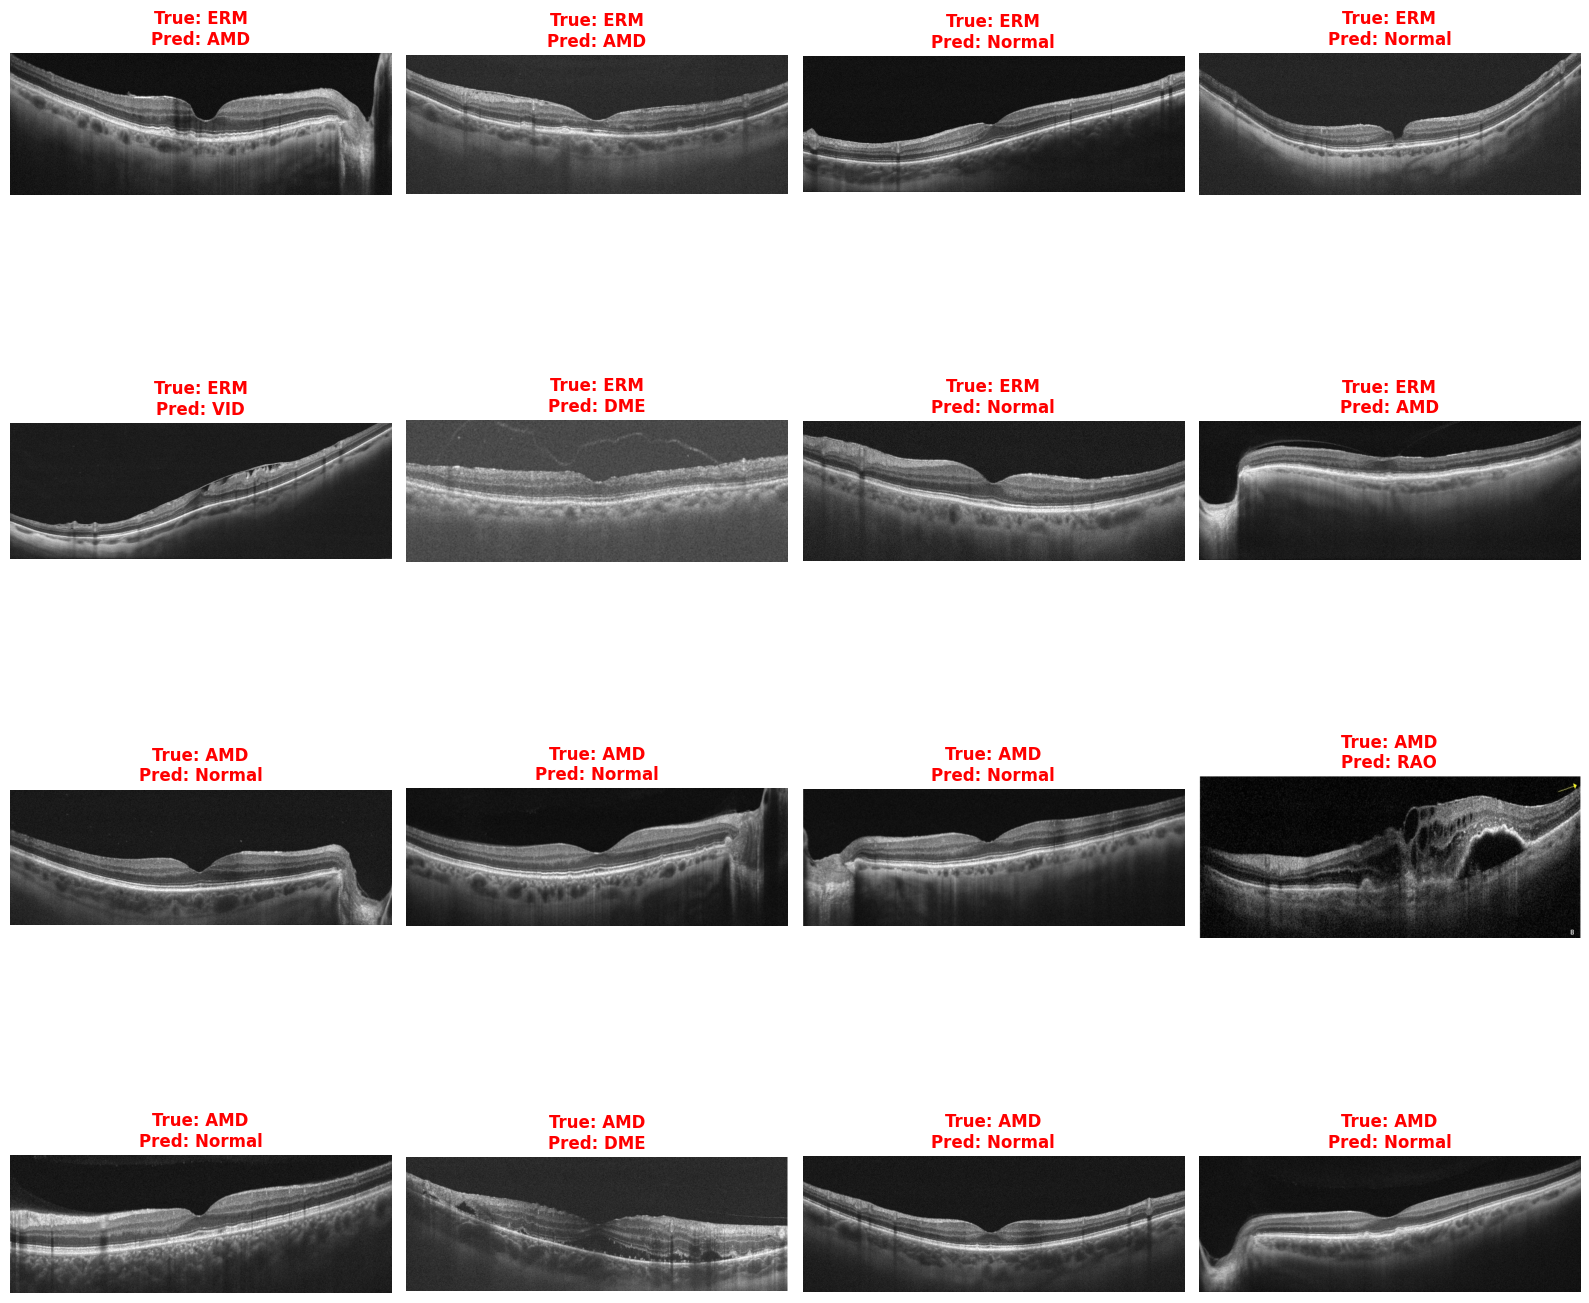

✅ Figure 6 (Failure Analysis Grid) successfully generated and saved to results/figures/figure_6_failure_analysis.png!


In [35]:
# Section 13.6: Representative Failure Analysis Grid
import os
import torch
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchvision.transforms as T
from src.dataset.dataset import RetinalDataset
from src.models.ae_resnet_v2.model import get_model_v2 as get_model_architecture

CLASSES = ['AMD', 'DME', 'ERM', 'Normal', 'RAO', 'RVO', 'VID']
val_transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])
test_dataset = RetinalDataset(test_df, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Load proposed AE-ResNet model
print("Loading proposed AE-ResNet model for failure analysis...")
model_inst = get_model_architecture('ae_resnet_v2', num_classes=7, pretrained=False).to(device)
if os.path.exists('models/ae_resnet_v2_best.pth'):
    model_inst.load_state_dict(torch.load('models/ae_resnet_v2_best.pth', map_location=device))
model_inst.eval()

# Run inference and locate misclassifications
misclass_records = []
with torch.no_grad():
    for idx, (images, targets) in enumerate(test_loader):
        images = images.to(device)
        outputs = model_inst(images)
        _, preds = torch.max(outputs, 1)

        preds_np = preds.cpu().numpy()
        targets_np = targets.numpy()

        for batch_idx in range(len(targets_np)):
            global_idx = idx * 16 + batch_idx  # 16 is test_loader batch size
            if preds_np[batch_idx] != targets_np[batch_idx]:
                img_path = test_df.iloc[global_idx]['image_path']
                misclass_records.append({
                    'image_path': img_path,
                    'true_label': CLASSES[targets_np[batch_idx]],
                    'pred_label': CLASSES[preds_np[batch_idx]]
                })

print(f"Total misclassified images found in test set: {len(misclass_records)}")

# Plot the first 16 misclassifications in a grid
n_plots = min(16, len(misclass_records))
if n_plots > 0:
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    axes_flat = axes.flatten()

    for i in range(16):
        ax = axes_flat[i]
        if i < n_plots:
            rec = misclass_records[i]
            img_pil = Image.open(rec['image_path']).convert('RGB')
            ax.imshow(img_pil)
            ax.set_title(f"True: {rec['true_label']}\nPred: {rec['pred_label']}", fontsize=12, fontweight='bold', color='red')
        ax.axis('off')

    plt.tight_layout()
    os.makedirs('results/figures', exist_ok=True)
    plt.savefig('results/figures/figure_6_failure_analysis.png', dpi=300)
    plt.show()
    print("✅ Figure 6 (Failure Analysis Grid) successfully generated and saved to results/figures/figure_6_failure_analysis.png!")
else:
    print("No misclassified cases found in the test set to display.")